# 03 — Position Reconstruction

**Goals**
- Q5: can we reconstruct position from acceleration? Challenges?
- Q6: implement reconstruction; show 2020-12-25 02:01–02:11; estimate stroke amplitude

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from well_analysis.data import load_test_data
from well_analysis.signal import check_even_sampling
from well_analysis.signal.integration import integrate_acceleration, estimate_gravity_offset
from well_analysis.detection import detect_well_state
from well_analysis.analysis.dynamometer import estimate_stroke_amplitude
from well_analysis.viz import plot_time_series

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = load_test_data()
_, fs = check_even_sampling(df['Timestamp'])
accel = df['Acceleration'].values
is_running = detect_well_state(accel, fs=fs)

## 1. Can we reconstruct position? Challenges (Q5)

Position = ∬ a(t) dt².

**Challenges**:
1. **Gravity offset**: raw acceleration includes −g + sensor bias → must be removed before integrating.
2. **Integration drift**: each integration of numerical noise adds a ramp (linear drift after 1st, quadratic after 2nd). Even tiny DC errors blow up.
3. **Initial conditions**: velocity and position at t=0 are unknown.

**Solution**: high-pass filter (cutoff ≪ pump freq ≈ 0.05 Hz, e.g. 0.02 Hz) applied after each integration step. This removes accumulated drift while preserving the oscillatory signal of interest.

## 1b. Why 0.02 Hz? — a frequency-domain view

The high-pass filter is an IIR (Butterworth, 4th order) — a pure time-domain
recursion, no FFT involved in the filtering itself.

But FFT is the right tool to **choose** the cutoff. The acceleration's power
spectrum shows three distinct regions:

- **DC / drift** (< 0.01 Hz): the enemy.
- **A quiet band** (≈ 0.01–0.04 Hz): the corridor we park the cutoff in.
- **Pump band** (≈ 0.05–0.1 Hz): the signal we want to keep.

Below we overlay the acceleration PSD with the filter's gain curve —
you can see the filter crushes the drift band by > 40 dB while passing
the pump band essentially unchanged (< 0.1 dB loss at 0.05 Hz).

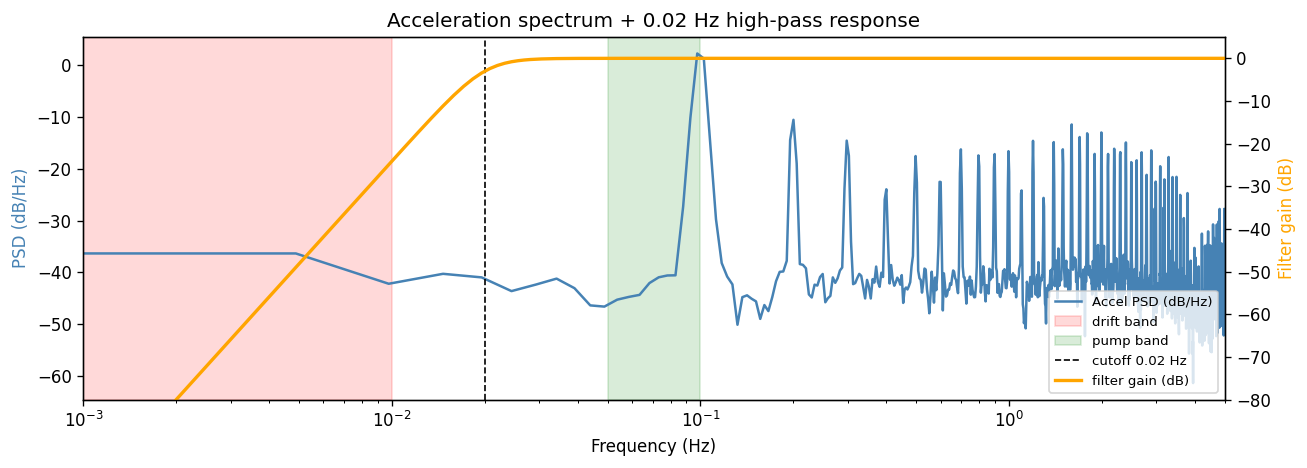

Filter gain at 0.005 Hz (drift) :  -47.9 dB
Filter gain at 0.02  Hz (cutoff):   -3.0 dB  (should be ~-3)
Filter gain at 0.05  Hz (pump)  :   -0.0 dB  (should be ~0)


In [2]:
from scipy import signal as sp_signal

# Welch PSD on a running segment (cleaner than whole 21 days)
t0 = pd.Timestamp('2020-12-25T02:01:00', tz='UTC')
t1 = pd.Timestamp('2020-12-25T02:11:00', tz='UTC')
seg = accel[(df['Timestamp'] >= t0) & (df['Timestamp'] < t1)]
seg = seg - np.median(seg)

freqs, psd = sp_signal.welch(seg, fs=fs, nperseg=min(len(seg), 2048))

# Filter frequency response
sos  = sp_signal.butter(4, 0.02, btype='high', fs=fs, output='sos')
w, h = sp_signal.sosfreqz(sos, worN=4096, fs=fs)
gain_db = 20 * np.log10(np.maximum(np.abs(h), 1e-6))

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.semilogx(freqs, 10*np.log10(psd + 1e-20), color='steelblue', label='Accel PSD (dB/Hz)')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('PSD (dB/Hz)', color='steelblue')
ax1.set_xlim(1e-3, fs/2)
ax1.axvspan(0,    0.01, alpha=0.15, color='red',    label='drift band')
ax1.axvspan(0.05, 0.10, alpha=0.15, color='green',  label='pump band')
ax1.axvline(0.02, color='k', ls='--', lw=1, label='cutoff 0.02 Hz')

ax2 = ax1.twinx()
ax2.semilogx(w, gain_db, color='orange', lw=2, label='filter gain (dB)')
ax2.set_ylabel('Filter gain (dB)', color='orange')
ax2.set_ylim(-80, 5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
ax1.set_title('Acceleration spectrum + 0.02 Hz high-pass response')
plt.tight_layout(); plt.show()

# Quantitative check
def gain_at(f):
    return float(np.interp(f, w, np.abs(h)))
print(f'Filter gain at 0.005 Hz (drift) : {20*np.log10(gain_at(0.005)):6.1f} dB')
print(f'Filter gain at 0.02  Hz (cutoff): {20*np.log10(gain_at(0.02 )):6.1f} dB  (should be ~-3)')
print(f'Filter gain at 0.05  Hz (pump)  : {20*np.log10(gain_at(0.05 )):6.1f} dB  (should be ~0)')

In [3]:
# Estimate gravity offset from stopped intervals
g_offset = estimate_gravity_offset(accel, is_running)
print(f"Gravity offset estimate: {g_offset:.4f} m/s²  (expected ≈ -9.81)")

velocity, position = integrate_acceleration(accel, fs=fs, gravity_offset=g_offset, hp_cutoff=0.02)

Gravity offset estimate: 9.5393 m/s²  (expected ≈ -9.81)


## 2. Show reconstruction 2020-12-25 02:01 → 02:11 (Q6)

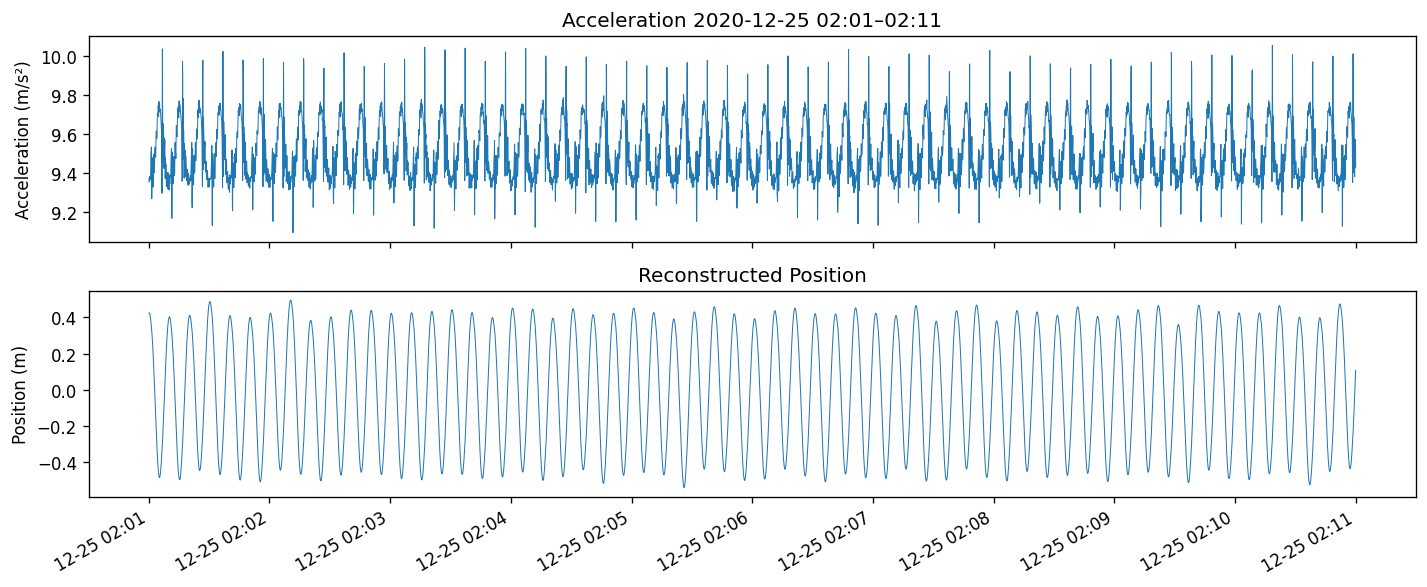

In [4]:
t_start = pd.Timestamp('2020-12-25T02:01:00', tz='UTC')
t_end   = pd.Timestamp('2020-12-25T02:11:00', tz='UTC')
mask = (df['Timestamp'] >= t_start) & (df['Timestamp'] < t_end)

ts_sub  = df.loc[mask, 'Timestamp']
acc_sub = accel[mask]
pos_sub = position[mask]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
plot_time_series(ts_sub, acc_sub, ylabel='Acceleration (m/s²)',
                 title='Acceleration 2020-12-25 02:01–02:11', ax=axes[0])
plot_time_series(ts_sub, pos_sub, ylabel='Position (m)',
                 title='Reconstructed Position', ax=axes[1])
plt.tight_layout()
plt.show()

In [5]:
stroke = estimate_stroke_amplitude(pos_sub)
print(f"Estimated stroke amplitude: {stroke:.3f} m  ({stroke*100:.1f} cm)")

Estimated stroke amplitude: 0.960 m  (96.0 cm)
